<a href="https://colab.research.google.com/github/AatmajRakshe/Synapse_Tasks/blob/ML/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

In [9]:
#import all the prerequisites like tensorflow and keras
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense,Activation,LeakyReLU
from sklearn.model_selection import train_test_split
import re
from keras.optimizers import SGD,Adam
import numpy as np
from numpy.random import seed
import tensorflow as tf
import random as rn
seed(100)
rn.seed(100)
tf.random.set_seed(100)

In [25]:
model=Sequential([
    Dense(64, input_shape=(13,)),
    LeakyReLU(alpha=0.1),
    Dense(32),
    LeakyReLU(alpha=0.1),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [5]:
df = pd.read_csv('/content/drive/MyDrive/DataSet/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df' is your DataFrame
columns_to_normalize = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.708333,1,3,0.481132,0.244292,1,0,0.603053,0,0.370968,0,0,1,1
1,0.166667,1,2,0.339623,0.283105,0,1,0.885496,0,0.564516,0,0,2,1
2,0.250000,0,1,0.339623,0.178082,0,0,0.770992,0,0.225806,2,0,2,1
3,0.562500,1,1,0.245283,0.251142,0,1,0.816794,0,0.129032,2,0,2,1
4,0.583333,0,0,0.245283,0.520548,0,1,0.702290,1,0.096774,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.583333,0,0,0.433962,0.262557,0,1,0.396947,1,0.032258,1,0,3,0
299,0.333333,1,3,0.150943,0.315068,0,1,0.465649,0,0.193548,1,0,3,0
300,0.812500,1,0,0.471698,0.152968,1,1,0.534351,0,0.548387,1,2,3,0
301,0.583333,1,0,0.339623,0.011416,0,1,0.335878,1,0.193548,1,1,3,0


In [7]:
y = df['target']
X = df.drop('target',axis=1)
X_train,X_test,y_train,y_test = train_test_split(X ,y , test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(212, 13)
(91, 13)
(212,)
(91,)


In [26]:
model.compile(optimizer=Adam(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=32,epochs=25)

Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4808 - loss: 1.4275
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7978 - loss: 0.4990 
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7339 - loss: 0.6302
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7805 - loss: 0.4828
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8107 - loss: 0.4568 
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8047 - loss: 0.4580 
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8052 - loss: 0.3855
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8540 - loss: 0.3642 
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8516 - loss: 0.3732 
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8538 - loss: 0.3681
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8403 - loss: 0.3426 
Epoch 12/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8730 - loss: 0.3397


In [27]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [32]:
y_pred_classes = (y_pred > 0.5).astype(int)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy*100}")


Accuracy: 85.71428571428571


In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_9 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,029 (35.27 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,020 (23.52 KB)

Confusion Matrix:
[[35  6]
 [ 7 43]]


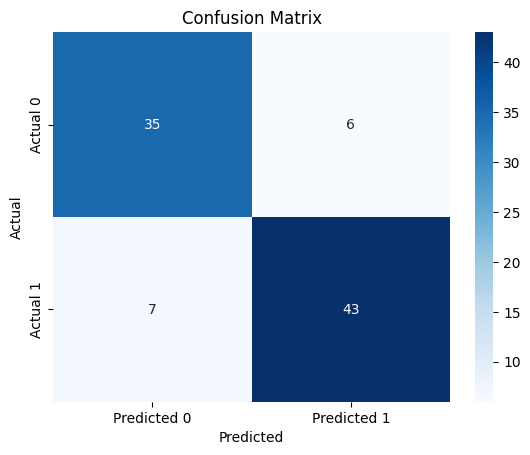

In [34]:
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_classes are defined from your previous code

conf_matrix = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(conf_matrix)

# You can also visualize the matrix (optional)
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [33]:
model.save('/content/drive/MyDrive/heart_disease_model.h5')